### **🎓 Research Assistant — MCP + LangGraph + Ollama + Firecrawl**

This notebook connects to your MCP server (running separately via `python server.py`)  
and provides an interactive LangGraph‑powered research assistant with:

- Firecrawl web scraping tools  
- Chroma‑based RAG retrieval  
- Topic management utilities  
- Local LLM inference via Ollama  

Make sure the MCP server is running before executing the cells below.

#### 📦 Client Dependencies
Load all required libraries for the LangGraph research agent, including the LLM interface, MCP client, graph utilities, and environment variables.

In [1]:
import asyncio
from pathlib import Path
from typing import List, Annotated
from typing_extensions import TypedDict

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_ollama import ChatOllama
from langgraph.prebuilt import tools_condition, ToolNode
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_mcp_adapters.client import MultiServerMCPClient

import os, json
from dotenv import load_dotenv

load_dotenv()

True

#### 📁 Load MCP Configuration

Load the multi‑server MCP configuration and inject environment variables.

In [2]:
parent_dir = Path.cwd().parent
mcp_config_path = parent_dir / "mcp.json"

with open(mcp_config_path, "r") as f:
    mcp_json = json.load(f)

# Inject Firecrawl API key
mcp_json["firecrawl_server"]["env"] = {
    "FIRECRAWL_API_KEY": os.getenv("FIRECRAWL_API_KEY")
}

mcp_json["research_server"]["cwd"] = str(parent_dir)

client = MultiServerMCPClient(mcp_json)

#### 🧠 Build the LangGraph Research Agent

Construct the agent, bind MCP tools, and define the workflow graph.

In [3]:
async def create_research_agent():
    # Local LLM
    llm = ChatOllama(model="qwen3", base_url=os.getenv("OLLAMA_BASE_URL"))

    # Load MCP tools
    tools = await client.get_tools()
    llm_with_tools = llm.bind_tools(tools)

    # System prompt
    system_message = """You are an advanced research assistant with access to web crawling and knowledge storage capabilities.

    Your abilities:
    1. Web Research — Use Firecrawl tools to scrape and analyze web content
    2. Knowledge Storage — Save important research findings to vector databases organized by topic
    3. Information Retrieval — Search through previously saved research using semantic similarity
    4. Research Management — Organize and manage research topics

    Guidelines:
    - Search existing knowledge before crawling new content
    - Save important findings to the appropriate topic
    - Provide structured, well‑reasoned answers
    """

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", system_message),
        MessagesPlaceholder("messages")
    ])

    chat_llm = prompt_template | llm_with_tools

    # LangGraph state
    class State(TypedDict):
        messages: Annotated[List[AnyMessage], add_messages]

    def chat_node(state: State) -> State:
        response = chat_llm.invoke({"messages": state["messages"]})
        return {"messages": [response]}

    # Build graph
    graph = StateGraph(State)
    graph.add_node("chat_node", chat_node)
    graph.add_node("tool_node", ToolNode(tools=tools))

    graph.add_edge(START, "chat_node")
    graph.add_conditional_edges(
        "chat_node",
        tools_condition,
        {"tools": "tool_node", "__end__": END}
    )
    graph.add_edge("tool_node", "chat_node")

    return graph.compile(checkpointer=MemorySaver()), tools

#### 🚀 Initialize the Agent

Create the agent instance and display all available MCP tools.

In [4]:
agent, tools = await create_research_agent()

print("📚 Available Tools:")
for t in tools:
    print(" •", t.name)

📚 Available Tools:
 • save_research_data
 • search_research_data
 • list_research_topics
 • delete_research_topic
 • get_topic_info
 • firecrawl_scrape
 • firecrawl_map
 • firecrawl_search
 • firecrawl_crawl
 • firecrawl_check_crawl_status
 • firecrawl_extract
 • firecrawl_agent
 • firecrawl_agent_status
 • firecrawl_browser_create
 • firecrawl_browser_execute
 • firecrawl_browser_delete
 • firecrawl_browser_list


### ❓ Helper Function — Single‑turn Query

Utility function for sending one message to the agent and returning its response.

In [5]:
async def ask(query: str):
    response = await agent.ainvoke(
        {"messages": [{"role": "user", "content": query}]},
        config={"configurable": {"thread_id": "notebook_session"}}
    )
    return response["messages"][-1].content

#### 🧪 Example Query

Run a sample research query to verify the agent is working correctly.

In [6]:
await ask("Research the latest developments in AI agents.")

"Here's an analysis of the latest developments in AI agents based on recent research and industry trends:\n\n### 1. **Evolution from Generative to Agentic AI (2023-2024)**\n- **Autonomous Task Management**: Companies like OpenAI, Anthropic, and Microsoft have pioneered AI agents capable of managing complex tasks through reasoning and context awareness (dotsolved.com, 2023).\n- **Integration with Emerging Tech**: AI agents are now being integrated with IoT and blockchain to enable decentralized systems and smart contracts (dotsolved.com).\n\n### 2. **Advanced Capabilities in 2024**\n- **Multistep Reasoning**: Agents can handle multi-step workflows, automate repetitive tasks, and manage complex operations through improved memory systems and reinforcement learning (LangChain Report, 2024).\n- **Contextual Understanding**: Enhanced context management allows agents to maintain coherent interactions across extended dialogues and tasks.\n\n### 3. **Applications in Customer Experience (CX)**\n

#### 🔁 Helper Function — Multi‑turn Chat

Simulate a conversational session by maintaining message history.

In [7]:
history = []

async def chat_turn(query):
    history.append({"role": "user", "content": query})
    response = await ask(query)
    history.append({"role": "assistant", "content": response})
    return response

#### 💬 Interactive Chat

Send multi‑turn queries to the agent using the helper function.

In [8]:
await chat_turn("What topics have I researched?")

"Here are the research topics you've explored recently:\n\n1. **Amazon-Stock-Analysis** (5 documents)\n2. **Google-Stock-Analysis** (5 documents)\n3. **Microsoft-Stock-Analysis** (5 documents)\n\nWould you like to review details about any of these topics or explore new research areas?"

In [9]:
await chat_turn("Search my research on Amazon Stock Analysis.")

'Here\'s a structured summary of your **Amazon Stock Analysis** research findings:\n\n---\n\n### **1. Current Stock Price (as of latest data)**\n- **AMZN (Class A):** $248.28 (down 0.91% in 24h)\n- **Price Range:** $245.37 - $256.15 (24h fluctuation)\n- **Current Price:** $250.74 (Robinhood data)\n*Source:* [TradingView](https://www.tradingview.com/symbols/NASDAQ-AMZN/), [Robinhood](https://robinhood.com/us/en/stocks/AMZN/)\n\n---\n\n### **2. Analyst Ratings & Price Targets**\n- **Average Rating:** "Strong Buy" (43 analysts)\n- **12-Month Target:** $281.95 (13.56% increase from current price)\n*Source:* [StockAnalysis.com](https://stockanalysis.com/stocks/amzn/)\n\n---\n\n### **3. Key Factors Influencing Price**\n- **Market Conditions:**\n  - Tech sector performance\n  - AI innovation trends\n- **Company News:**\n  - Strategic investments in AI (e.g., Anthropic)\n  - AWS growth initiatives\n- **Macroeconomic Factors:**\n  - Interest rates\n  - Consumer spending trends\n\n---\n\n### **4

#### **🎁 Bonus — Agent Workflow Visualization**

Generate a visual diagram of the LangGraph workflow to inspect how the `chat_node` and `tool_node` interact during tool‑calling execution.

In [10]:
png_bytes = agent.get_graph().draw_mermaid_png()

with open("graph.png", "wb") as f:
    f.write(png_bytes)

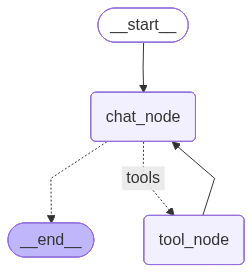

In [11]:
from IPython.display import Image, display

display(Image(data=png_bytes))